<a href="https://colab.research.google.com/github/IGichuki/SupervisedLearning-Classification-/blob/main/EmployeeAttrition__Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# BBT 3201: Artificial Intelligence - Practical CAT 2
**Dataset:** Employee Attrition
**Eager Classifier:** Decision Trees

### Group Members:
* [Member 1 Name] - [Student ID]
* [Member 2 Name] - [Student ID]
* [Member 3 Name] - [Student ID]

## Objective
The objective of this task is to build classification models to predict employee attrition.
We compare a lazy learner (k-Nearest Neighbours) and an eager learner (Decision Tree) using a carefully selected set of meaningful features derived from exploratory data analysis.

*(Insert group photo or meeting minutes here as evidence of teamwork.)*

SyntaxError: invalid syntax (1203829133.py, line 2)

In [3]:
# 1. Load and clean dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("EmployeeAttrition.csv")

# Drop irrelevant columns (identifiers or constant values)
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=cols_to_drop)

print(f"Remaining columns: {df_clean.shape[1]}")
df_clean.head()

Remaining columns: 31


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


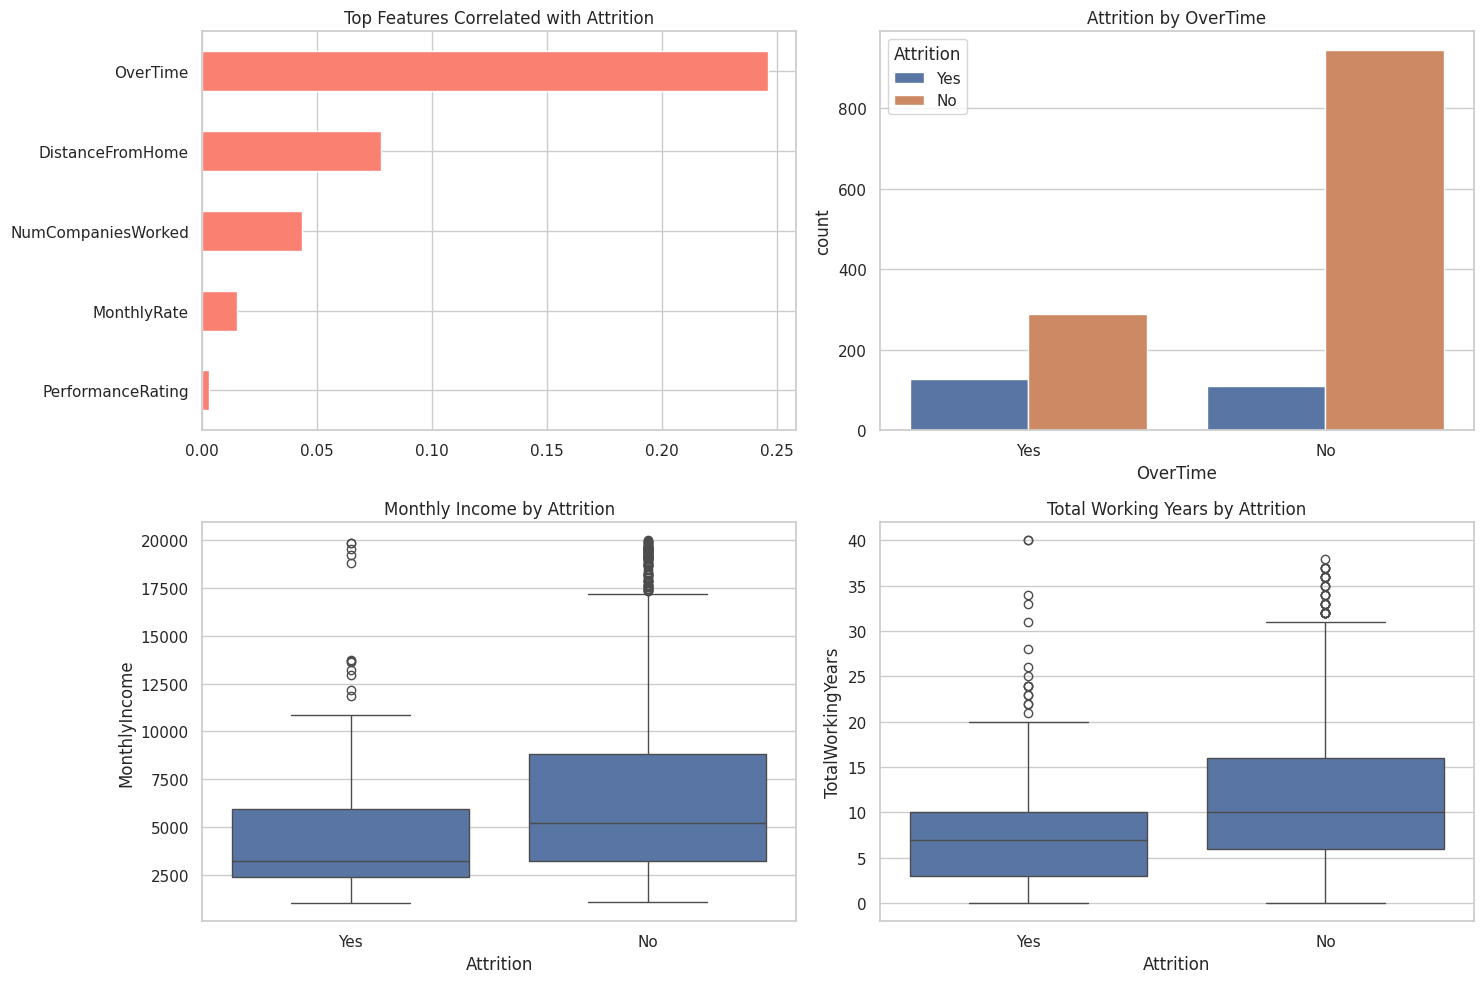

In [4]:
# 2. EDA + Correlation + Visualization
from sklearn.preprocessing import LabelEncoder

df_corr = df_clean.copy()

# Encode relevant categorical variables for correlation
le = LabelEncoder()
df_corr['Attrition'] = le.fit_transform(df_corr['Attrition'])
df_corr['OverTime'] = le.fit_transform(df_corr['OverTime'])

# Correlation analysis
correlations = df_corr.corr(numeric_only=True)['Attrition'].sort_values()

# Visualization
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Correlation plot
correlations.drop('Attrition').tail(5).plot(kind='barh', ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Top Features Correlated with Attrition')

# Overtime
sns.countplot(x='OverTime', hue='Attrition', data=df_clean, ax=axes[0, 1])
axes[0, 1].set_title('Attrition by OverTime')

# Income
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_clean, ax=axes[1, 0])
axes[1, 0].set_title('Monthly Income by Attrition')

# Experience
sns.boxplot(x='Attrition', y='TotalWorkingYears', data=df_clean, ax=axes[1, 1])
axes[1, 1].set_title('Total Working Years by Attrition')

plt.tight_layout()
plt.show()

In [5]:
### Key Observations:
1. **OverTime** shows one of the strongest observable relationships with attrition based on both correlation and visual analysis.
2. **Monthly Income** has a negative relationship with attrition, indicating that lower-paid employees are more likely to leave.
3. Employees with fewer **Total Working Years** tend to leave more frequently, suggesting experience influences retention.
4. **Age** is also related to attrition, with younger employees showing higher turnover.

### Feature Selection Justification:
To avoid the curse of dimensionality (especially for kNN) and reduce noise, we selected a small, meaningful set of features rather than using all available variables.

**Selected Features:** `OverTime`, `MonthlyIncome`, `Age`, `TotalWorkingYears`

These features were chosen because they are both statistically relevant (based on correlation analysis) and intuitively meaningful in explaining employee behavior. Using a limited number of strong features improves model interpretability, reduces overfitting, and ensures more reliable predictions.

Additionally, the exact same feature set is used across all models to ensure a fair comparison.

SyntaxError: invalid syntax (1485735938.py, line 2)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_encoded = df_clean.copy()

# Encode target
df_encoded['Attrition'] = LabelEncoder().fit_transform(df_encoded['Attrition'])

# Encode OverTime
df_encoded = pd.get_dummies(df_encoded, columns=['OverTime'], drop_first=True)

# Selected features
selected_features = ['OverTime_Yes', 'MonthlyIncome', 'Age', 'TotalWorkingYears']

X = df_encoded[selected_features]
y = df_encoded['Attrition']

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale for kNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_range = range(1, 21)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

optimal_k = k_range[np.argmax(accuracies)]

print("Selected Features:", selected_features)
print("Optimal k:", optimal_k)

# Final model
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_scaled, y_train)

Selected Features: ['OverTime_Yes', 'MonthlyIncome', 'Age', 'TotalWorkingYears']
Optimal k: 18


KNeighborsClassifier(n_neighbors=18)

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

tuned_dt_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 5}


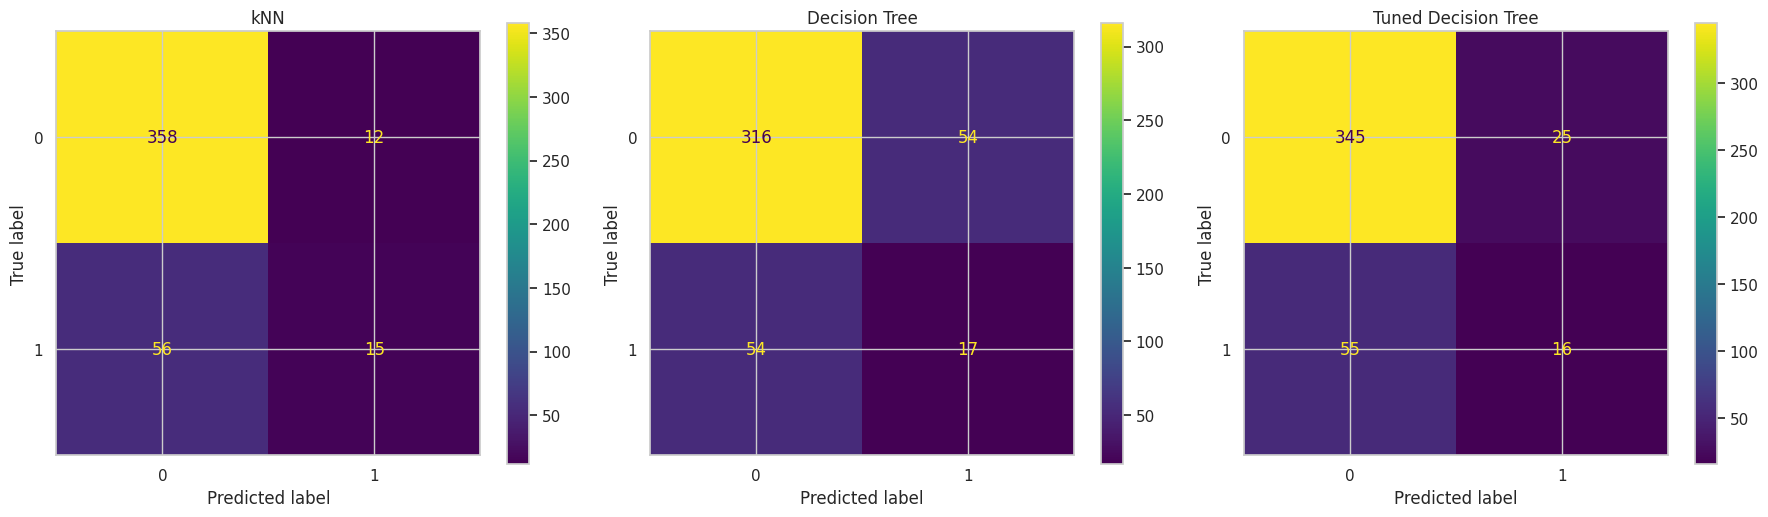

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test)
y_pred_tuned_dt = tuned_dt_model.predict(X_test)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=axes[0])
axes[0].set_title("kNN")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1])
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned_dt, ax=axes[2])
axes[2].set_title("Tuned Decision Tree")

plt.tight_layout()
plt.show()

In [11]:
## Model Performance Comparison

- The kNN model performs well but is sensitive to the choice of k and requires feature scaling since it is distance-based.
- The baseline Decision Tree tends to overfit because it grows without restriction, capturing noise in the training data.
- The tuned Decision Tree improves performance by controlling tree depth and splitting criteria, leading to better generalization.

## Conclusion

The tuned Decision Tree model provides the best performance among the three models.

## Key Learning Points

- Feature selection improves interpretability and reduces overfitting.
- kNN requires scaling due to its reliance on distance.
- Decision Trees are powerful but must be tuned to avoid overfitting.
- Using the same feature set ensures a fair and valid comparison between models.

SyntaxError: invalid syntax (3295652145.py, line 3)

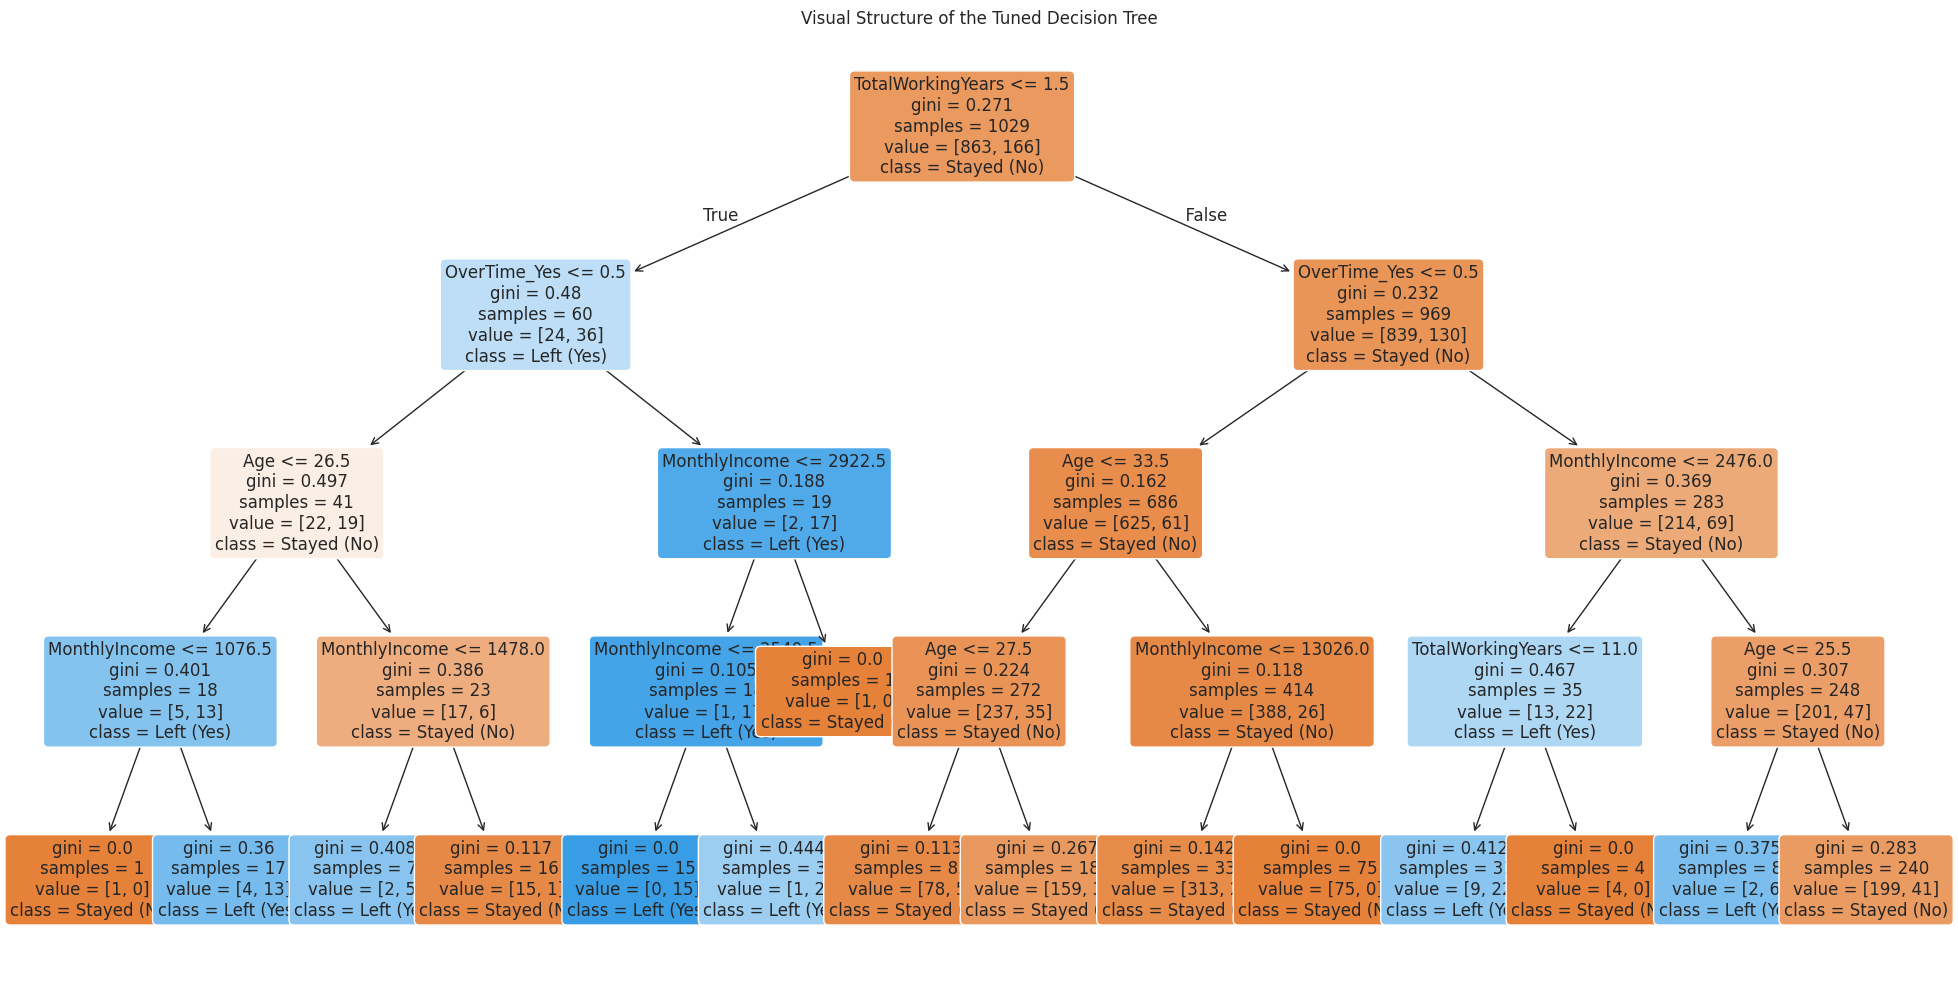

In [12]:
# 7. BONUS: Visualize the Tuned Decision Tree structure
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tuned_dt_model,
    feature_names=selected_features,
    class_names=['Stayed (No)', 'Left (Yes)'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Visual Structure of the Tuned Decision Tree")
plt.tight_layout()
plt.show()